<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/RealMLPandTabM_Toniot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1 — CONFIG

DRIVE_DATASET = "/content/drive/MyDrive/datasets/toniot_arnob_dataset"
DRIVE_OUT_DIR = "/content/drive/MyDrive/toniot_outputs"

LABEL_COL   = "type"
RANDOM_SEED = 42
TEST_SIZE   = 0.2
VAL_SIZE    = 0.1

# Training settings
N_EPOCHS_GRANDE = 50
N_EPOCHS_TABM      = 256
EARLY_STOPPING     = 20   # stop if no improvement for 20 epochs
BATCH_SIZE      = 512
DEVICE          = "cuda"

In [2]:
# CELL 2 — INSTALL

!pip install -q pytabkit
!pip install -q tabm
!pip install -q scikit-learn pandas numpy matplotlib seaborn

print(" All packages installed — now restart runtime!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.4 MB/s eta 0:00:00
 All packages installed — now restart runtime!


In [ ]:
# CELL 3 — IMPORTS + DRIVE + GPU CHECK

import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

# GPU check will crash if no GPU
if not torch.cuda.is_available():
    raise RuntimeError(
        "\n\n NO GPU DETECTED!\n"
        "→ Go to Runtime - Change runtime type\n"
        "→ Select T4 GPU\n"
        "→ Click Save\n"
        "→ Re-run from Cell 1\n"
    )

device = torch.device("cuda")
print(f" GPU confirmed : {torch.cuda.get_device_name(0)}")
print(f" VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f" Device        : {device}")

Mounted at /content/drive
 GPU confirmed : Tesla T4
 VRAM          : 15.6 GB
 Device        : cuda


In [ ]:
# CELL 4 — LOAD DATA

csv_files = glob.glob(os.path.join(DRIVE_DATASET, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    try:
        dfs.append(pd.read_csv(f, low_memory=False))
    except Exception as e:
        print(f"  Skipped {f}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"\nLabel distribution:\n{df[LABEL_COL].value_counts()}")

Found 1 CSV files
Total rows: 211,043  |  Columns: 44

Label distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


In [ ]:
# CELL 5 — PREPROCESS


# Drop label + non-feature columns
drop_cols = [LABEL_COL]
for col in ["ts", "src_ip", "dst_ip", "src_mac", "dst_mac"]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y_raw = df[LABEL_COL]

# Encode string labels to integers
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

# Keep numeric only + replace inf
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Features: {X.shape[1]}")

# ─ Split FIRST before any imputation or scaling
# 70 / 10 / 20 split
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED,
    stratify=y_tv)

print(f"\nTrain : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

# Impute NaN using TRAIN median only
# This prevents data leakage
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)

# Scale using TRAIN statistics only
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

n_features = X_train_s.shape[1]
print(f"\nFeatures after preprocessing : {n_features}")
print(" Preprocessing complete — no data leakage")

Classes (10): ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Features: 17

Train : 147,729
Val   : 21,105
Test  : 42,209

Features after preprocessing : 17
 Preprocessing complete — no data leakage


In [ ]:
# CELL 6 — EVALUATION HELPER

def evaluate(model_name, y_true, y_pred, label_names, out_dir):
    acc        = accuracy_score(y_true, y_pred)
    f1_macro   = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} — Results")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weighted:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_names, zero_division=0)}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    path = os.path.join(out_dir, f"{model_name.lower().replace(' ','_')}_cm.png")
    plt.savefig(path, dpi=150); plt.show()
    print(f"Saved: {path}")

    return {"model": model_name, "accuracy": acc,
            "f1_macro": f1_macro, "f1_weighted": f1_weighted}

In [ ]:
# CELL 7 — RealMLP

from pytabkit import RealMLP_TD_Classifier

realmlp_model = RealMLP_TD_Classifier(
    random_state=RANDOM_SEED,
    verbosity=1,          # print epoch progress
    device='cuda' if torch.cuda.is_available() else 'cpu',
)

print("Training RealMLP...")
realmlp_model.fit(
    X_train_s, y_train,   # training data
    X_val_s,   y_val      # validation data for early stopping
)
print("RealMLP training complete.")

Training RealMLP...
Columns classified as continuous: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Columns classified as categorical: []


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero: Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=256` reached.


RealMLP training complete.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero: Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  RealMLP — Results
  Accuracy      : 0.9875
  F1 (macro)    : 0.9593
  F1 (weighted) : 0.9875

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      4000
        ddos       0.98      0.98      0.98      4000
         dos       0.99      0.98      0.98      4000
   injection       0.97      0.96      0.97      4000
        mitm       0.67      0.75      0.71       209
      normal       1.00      1.00      1.00     10000
    password       0.99      0.99      0.99      4000
  ransomware       1.00      1.00      1.00      4000
    scanning       0.98      0.99      0.99      4000
         xss       0.97      0.98      0.98      4000

    accuracy                           0.99     42209
   macro avg       0.96      0.96      0.96     42209
weighted avg       0.99      0.99      0.99     42209



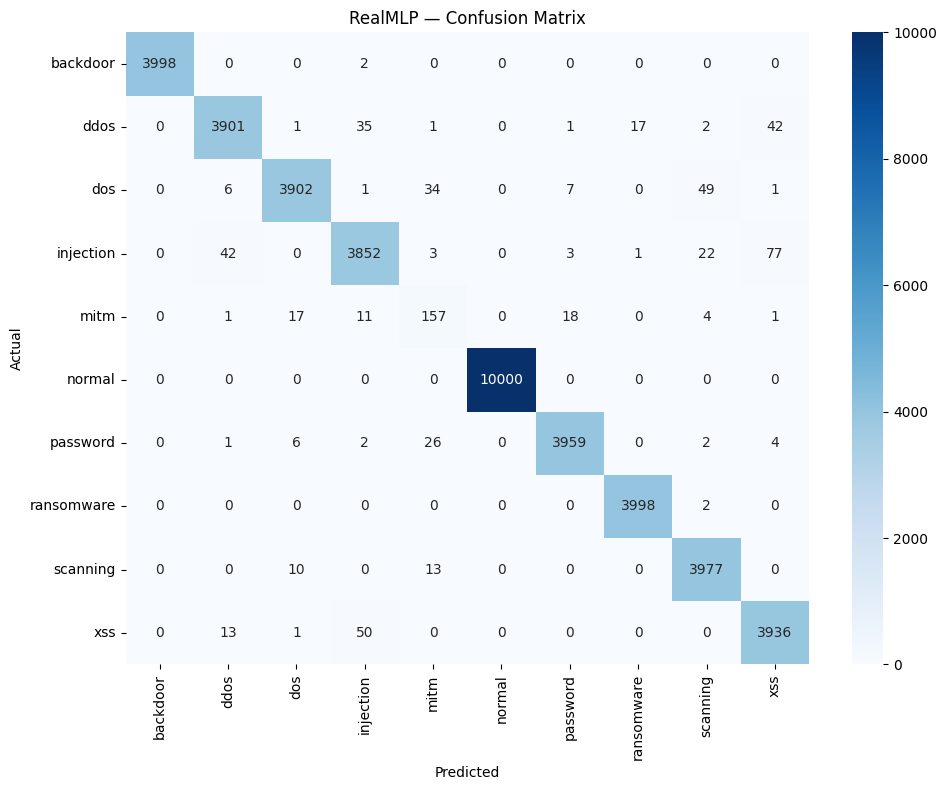

Saved: /content/drive/MyDrive/toniot_outputs/realmlp_cm.png


In [ ]:
# CELL 8 — RealMLP TEST EVALUATION

realmlp_preds = realmlp_model.predict(X_test_s)

realmlp_results = evaluate(
    "RealMLP", y_test, realmlp_preds,
    label_names=list(le.classes_),
    out_dir=DRIVE_OUT_DIR
)

In [ ]:

# CELL 9 — TabM
from tabm import TabM

X_tr = torch.tensor(X_train_s, dtype=torch.float32)
X_v  = torch.tensor(X_val_s,   dtype=torch.float32)
X_te = torch.tensor(X_test_s,  dtype=torch.float32)
y_tr = torch.tensor(y_train,   dtype=torch.long)
y_v  = torch.tensor(y_val,     dtype=torch.long)
y_te = torch.tensor(y_test,    dtype=torch.long)

train_dl = DataLoader(TensorDataset(X_tr, y_tr),
                      batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(TensorDataset(X_v,  y_v),
                      batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(TensorDataset(X_te, y_te),
                      batch_size=BATCH_SIZE, shuffle=False)

tabm_model = TabM.make(
    n_num_features=n_features,
    cat_cardinalities=[],
    d_out=num_classes,
).to(device)

optimizer = torch.optim.AdamW(
    tabm_model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

print(f"TabM params : {sum(p.numel() for p in tabm_model.parameters()):,}")
print(f"Device      : {device}")
print(f"Max epochs  : {N_EPOCHS_TABM}")
print(f"Early stop  : {EARLY_STOPPING} epochs patience")
print("Training TabM...")

best_val_f1       = 0
best_state        = None
tabm_history      = []
no_improve_count  = 0   # early stopping counter

for epoch in range(1, N_EPOCHS_TABM + 1):
    #  Train
    tabm_model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(tabm_model(xb).mean(dim=1), yb)
        loss.backward()
        optimizer.step()

    #  Validate
    tabm_model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            p = tabm_model(xb.to(device)).mean(dim=1)\
                          .argmax(dim=-1).cpu().numpy()
            preds_all.extend(p)
            true_all.extend(yb.numpy())

    val_f1  = f1_score(true_all, preds_all,
                       average="macro", zero_division=0)
    val_acc = accuracy_score(true_all, preds_all)
    tabm_history.append({"epoch": epoch,
                         "val_f1": val_f1, "val_acc": val_acc})

    print(f"  Epoch {epoch:03d}/{N_EPOCHS_TABM} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f} | "
          f"No improve: {no_improve_count}/{EARLY_STOPPING}")

    # Save best / early stopping
    if val_f1 > best_val_f1:
        best_val_f1      = val_f1
        best_state       = {k: v.cpu()
                            for k, v in tabm_model.state_dict().items()}
        no_improve_count = 0
        print(f"   New best F1: {best_val_f1:.4f} — model saved")
    else:
        no_improve_count += 1
        if no_improve_count >= EARLY_STOPPING:
            print(f"\n⏹ Early stopping at epoch {epoch} "
                  f"— no improvement for {EARLY_STOPPING} epochs")
            break

print(f"\nBest Val F1 (TabM): {best_val_f1:.4f} ")

TabM params : 828,768
Device      : cuda
Max epochs  : 256
Early stop  : 20 epochs patience
Training TabM...
  Epoch 001/256 | Val Acc: 0.7968 | Val F1: 0.6947 | No improve: 0/20
   New best F1: 0.6947 — model saved
  Epoch 002/256 | Val Acc: 0.8281 | Val F1: 0.7384 | No improve: 0/20
   New best F1: 0.7384 — model saved
  Epoch 003/256 | Val Acc: 0.8679 | Val F1: 0.7696 | No improve: 0/20
   New best F1: 0.7696 — model saved
  Epoch 004/256 | Val Acc: 0.8816 | Val F1: 0.7960 | No improve: 0/20
   New best F1: 0.7960 — model saved
  Epoch 005/256 | Val Acc: 0.8982 | Val F1: 0.8204 | No improve: 0/20
   New best F1: 0.8204 — model saved
  Epoch 006/256 | Val Acc: 0.9046 | Val F1: 0.8225 | No improve: 0/20
   New best F1: 0.8225 — model saved
  Epoch 007/256 | Val Acc: 0.9277 | Val F1: 0.8539 | No improve: 0/20
   New best F1: 0.8539 — model saved
  Epoch 008/256 | Val Acc: 0.9409 | Val F1: 0.8696 | No improve: 0/20
   New best F1: 0.8696 — model saved
  Epoch 009/256 | Val Acc: 0.9421 |


  TabM — Results
  Accuracy      : 0.9793
  F1 (macro)    : 0.9453
  F1 (weighted) : 0.9793

              precision    recall  f1-score   support

    backdoor       0.99      1.00      1.00      4000
        ddos       0.97      0.96      0.97      4000
         dos       0.99      0.97      0.98      4000
   injection       0.95      0.95      0.95      4000
        mitm       0.68      0.63      0.65       209
      normal       1.00      1.00      1.00     10000
    password       0.99      0.99      0.99      4000
  ransomware       0.99      1.00      1.00      4000
    scanning       0.98      0.98      0.98      4000
         xss       0.94      0.96      0.95      4000

    accuracy                           0.98     42209
   macro avg       0.95      0.94      0.95     42209
weighted avg       0.98      0.98      0.98     42209



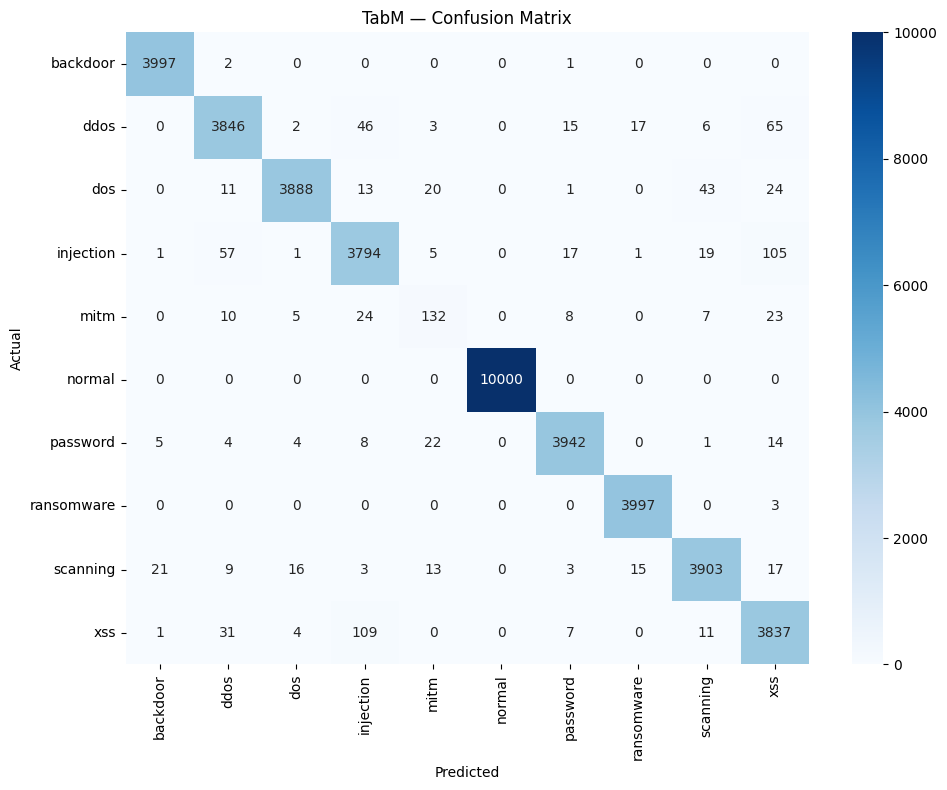

Saved: /content/drive/MyDrive/toniot_outputs/tabm_cm.png


In [ ]:
# CELL 10 — TabM TEST EVALUATION

tabm_model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
tabm_model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        preds = tabm_model(xb.to(device)).mean(dim=1).argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

tabm_results = evaluate(
    "TabM", all_true, all_preds,
    label_names=list(le.classes_),
    out_dir=DRIVE_OUT_DIR
)


========== FINAL COMPARISON ==========
         accuracy  f1_macro  f1_weighted
model                                   
RealMLP    0.9875    0.9593       0.9875
TabM       0.9793    0.9453       0.9793
Saved: /content/drive/MyDrive/toniot_outputs/toniot_realmlp_tabm_results.csv


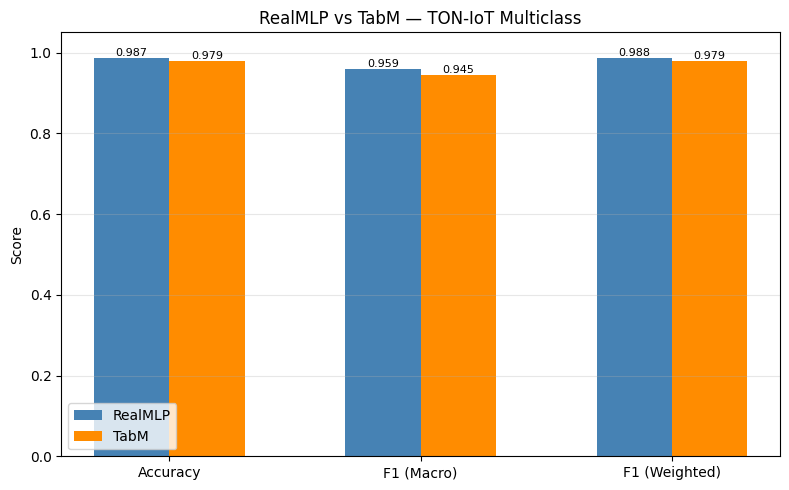

All results saved to /content/drive/MyDrive/toniot_outputs


In [ ]:
# CELL 11 — FINAL COMPARISON: RealMLP vs TabM

results_df = pd.DataFrame([realmlp_results, tabm_results]).set_index("model")
print("\n========== FINAL COMPARISON ==========")
print(results_df.round(4).to_string())

csv_path = os.path.join(DRIVE_OUT_DIR, "toniot_realmlp_tabm_results.csv")
results_df.to_csv(csv_path)
print(f"Saved: {csv_path}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
metrics = ["accuracy", "f1_macro", "f1_weighted"]
x = np.arange(len(metrics))
width = 0.3
bars1 = ax.bar(x - width/2, [realmlp_results[m] for m in metrics],
               width, label="RealMLP", color="steelblue")
bars2 = ax.bar(x + width/2, [tabm_results[m]   for m in metrics],
               width, label="TabM",    color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "F1 (Macro)", "F1 (Weighted)"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("RealMLP vs TabM — TON-IoT Multiclass")
ax.legend(); ax.grid(axis="y", alpha=0.3)
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2,
    bar.get_height()+0.005, f"{bar.get_height():.3f}", ha="center", fontsize=8)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2,
    bar.get_height()+0.005, f"{bar.get_height():.3f}", ha="center", fontsize=8)
plt.tight_layout()
bar_path = os.path.join(DRIVE_OUT_DIR, "toniot_realmlp_tabm_comparison.png")
plt.savefig(bar_path, dpi=150); plt.show()
print(f"All results saved to {DRIVE_OUT_DIR}")

In [ ]:
# DIAGNOSIS CELL — Overfitting / Underfitting Check


# RealMLP  get train score
realmlp_train_preds = realmlp_model.predict(X_train_s)
realmlp_train_f1    = f1_score(y_train, realmlp_train_preds,
                               average="macro", zero_division=0)
realmlp_train_acc   = accuracy_score(y_train, realmlp_train_preds)

print("=" * 50)
print("RealMLP")
print("=" * 50)
print(f"  Train Acc : {realmlp_train_acc:.4f}")
print(f"  Test  Acc : {realmlp_results['accuracy']:.4f}")
print(f"  Train F1  : {realmlp_train_f1:.4f}")
print(f"  Test  F1  : {realmlp_results['f1_macro']:.4f}")
gap_realmlp = realmlp_train_acc - realmlp_results['accuracy']
print(f"  Gap       : {gap_realmlp:.4f}")

# TabM  get train score
tabm_model.eval()
all_preds = []
with torch.no_grad():
    for xb, yb in DataLoader(TensorDataset(X_tr, y_tr),
                             batch_size=BATCH_SIZE):
        p = tabm_model(xb.to(device)).mean(dim=1).argmax(dim=-1).cpu().numpy()
        all_preds.extend(p)

tabm_train_f1  = f1_score(y_train, all_preds, average="macro", zero_division=0)
tabm_train_acc = accuracy_score(y_train, all_preds)

print()
print("=" * 50)
print("TabM")
print("=" * 50)
print(f"  Train Acc : {tabm_train_acc:.4f}")
print(f"  Test  Acc : {tabm_results['accuracy']:.4f}")
print(f"  Train F1  : {tabm_train_f1:.4f}")
print(f"  Test  F1  : {tabm_results['f1_macro']:.4f}")
gap_tabm = tabm_train_acc - tabm_results['accuracy']
print(f"  Gap       : {gap_tabm:.4f}")



INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero: Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


RealMLP
  Train Acc : 0.9922
  Test  Acc : 0.9875
  Train F1  : 0.9814
  Test  F1  : 0.9593
  Gap       : 0.0047

TabM
  Train Acc : 0.9814
  Test  Acc : 0.9793
  Train F1  : 0.9529
  Test  F1  : 0.9453
  Gap       : 0.0021
